---

# $k$-Nearest Neighbors

Attempts classification of wine by cultivar class.



---

## 1. Setup

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split

sns.set_theme()
plt.rcParams["figure.figsize"] = (10, 8)

---

## 2. Load the Wine Dataset

We use `sklearn.datasets.load_wine()` only to access the data. All modelling is done from scratch.

The dataset contains:
- **178 samples** of wine
- **13 numeric chemistry features** (alcohol, malic acid, ash, etc.)
- **3 cultivar classes** (0 = class_0, 1 = class_1, 2 = class_2)

---

In [2]:
data = load_wine()

X_df = pd.DataFrame(data.data, columns=data.feature_names)
y_s  = pd.Series(data.target, name="cultivar")

target_names  = list(data.target_names)
class_mapping = {i: name for i, name in enumerate(target_names)}

print("Feature matrix shape:", X_df.shape)
print("Target shape        :", y_s.shape)
print("\nClasses:", target_names)
print("\nClass distribution:")
print(y_s.value_counts().rename(index=class_mapping))

X_df.head()

Feature matrix shape: (178, 13)
Target shape        : (178,)

Classes: [np.str_('class_0'), np.str_('class_1'), np.str_('class_2')]

Class distribution:
cultivar
class_1    71
class_0    59
class_2    48
Name: count, dtype: int64


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0


In [3]:
X_df.describe().T

,count,mean,std,min,25%,50%,75%,max
alcohol,178.0,13.000618,0.811827,11.03,12.3625,13.050,13.6775,14.83
malic_acid,178.0,2.336348,1.117146,0.74,1.6025,1.865,3.0825,5.80
ash,178.0,2.366517,0.274344,1.36,2.2100,2.360,2.5575,3.23
alcalinity_of_ash,178.0,19.494944,3.339564,10.60,17.2000,19.500,21.5000,30.00
magnesium,178.0,99.741573,14.282484,70.00,88.0000,98.000,107.0000,162.00
total_phenols,178.0,2.295112,0.625851,0.98,1.7425,2.355,2.8000,3.88
flavanoids,178.0,2.029270,0.998859,0.34,1.2050,2.135,2.8750,5.08
nonflavanoid_phenols,178.0,0.361854,0.124453,0.13,0.2700,0.340,0.4375,0.66
proanthocyanins,178.0,1.590899,0.572359,0.41,1.2500,1.555,1.9500,3.58
color_intensity,178.0,5.058090,2.318286,1.28,3.2200,4.690,6.2000,13.00


---

## 3. Exploratory Data Analysis

KNN hinges on the assumption that *similar things are near each other*. Let us check whether wine classes cluster together in feature space.

---

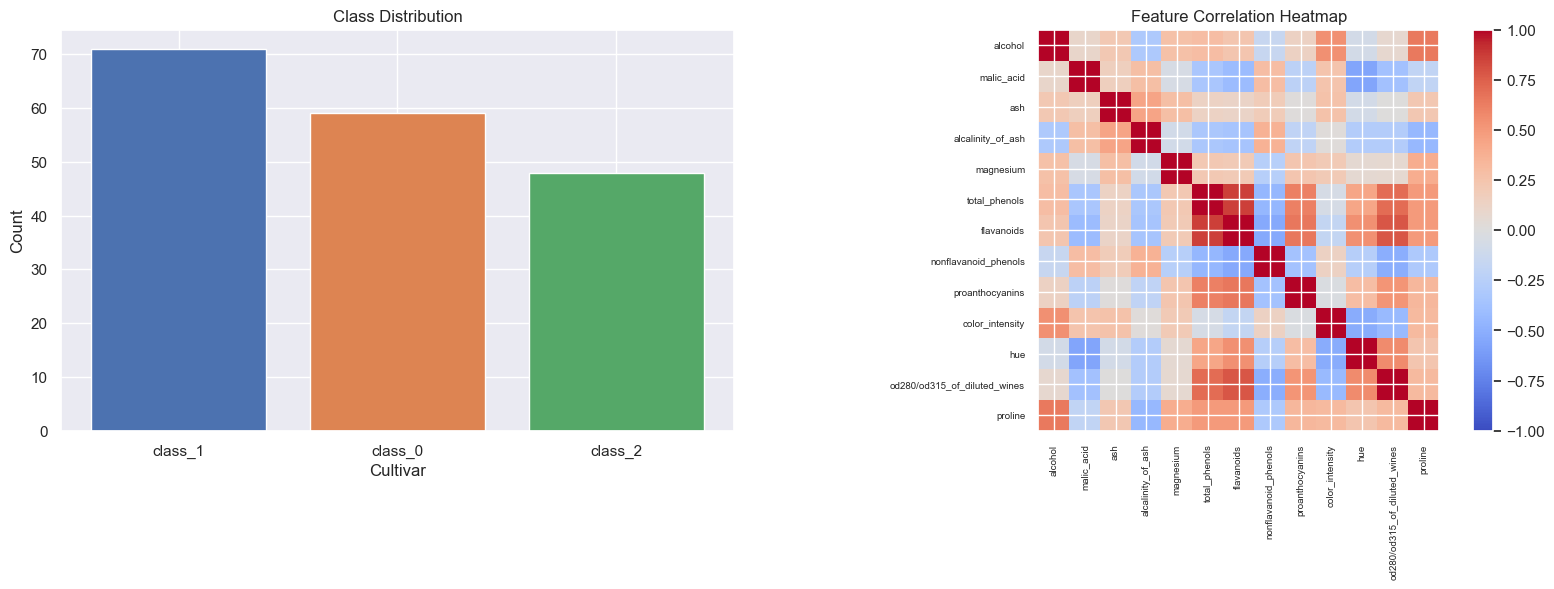

In [4]:
# Class distribution
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

counts = y_s.map(class_mapping).value_counts()
axes[0].bar(counts.index, counts.values, color=["C0", "C1", "C2"])
axes[0].set_title("Class Distribution")
axes[0].set_xlabel("Cultivar")
axes[0].set_ylabel("Count")

# Correlation heatmap
corr = X_df.corr()
im   = axes[1].imshow(corr.values, cmap="coolwarm", vmin=-1, vmax=1)
axes[1].set_xticks(range(len(corr.columns)))
axes[1].set_yticks(range(len(corr.columns)))
axes[1].set_xticklabels(corr.columns, rotation=90, fontsize=7)
axes[1].set_yticklabels(corr.columns, fontsize=7)
axes[1].set_title("Feature Correlation Heatmap")
plt.colorbar(im, ax=axes[1])

plt.tight_layout()
plt.show()

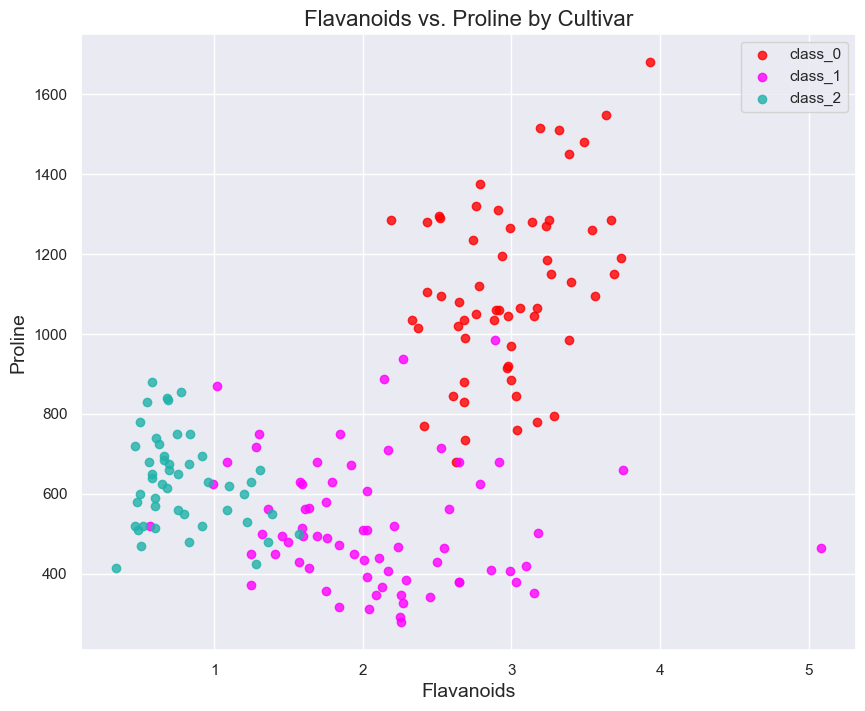

In [5]:
# Scatter plot of two highly discriminating features: flavanoids vs. proline
flowers = target_names
colors  = ["red", "magenta", "lightseagreen"]

fig, ax = plt.subplots(figsize=(10, 8))
for cls, color in zip(range(3), colors):
    mask = y_s == cls
    ax.scatter(X_df.loc[mask, "flavanoids"],
               X_df.loc[mask, "proline"],
               c=color,
               label=class_mapping[cls],
               alpha=0.8)

ax.set_xlabel("Flavanoids", fontsize=14)
ax.set_ylabel("Proline", fontsize=14)
ax.set_title("Flavanoids vs. Proline by Cultivar", fontsize=16)
ax.legend()
plt.show()

---

## 4. Train / Test Split

We set aside 33 % of the data for testing, using a stratified split so every class is equally represented in both sets.

---

In [6]:
X = X_df.to_numpy()
y = y_s.to_numpy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.33, stratify=y, random_state=42
)

print("Training set:", X_train.shape, y_train.shape)
print("Test set    :", X_test.shape,  y_test.shape)

Training set: (119, 13) (119,)
Test set    : (59, 13) (59,)


---

## 5. Euclidean Distance

We measure similarity using the **Euclidean distance**:

$$d(p, q) = \sqrt{(p - q)^{\top}(p - q)}$$

---

In [7]:
def distance(p, q):
    """Euclidean distance between two points."""
    diff = p - q
    return np.sqrt(diff @ diff)

# Quick sanity check
print(f"Distance between sample 0 and sample 50: {distance(X[0], X[50]):.4f}")

Distance between sample 0 and sample 50: 92.0092


---

## 6. $k$-Nearest Neighbors Algorithm

### Algorithm steps
1. For each query point, compute its distance to every training point.
2. Sort training points by distance (ascending).
3. Take the $k$ closest points.
4. Return the **majority label** (classification) or **mean label** (regression).

---

In [8]:
def k_nearest_neighbors(point, training_features, training_labels, k):
    """Return the k nearest (feature, label, distance) triples."""
    neighbors = []
    for p, label in zip(training_features, training_labels):
        d = distance(point, p)
        neighbors.append([p, label, d])
    neighbors.sort(key=lambda x: x[-1])
    return neighbors[:k]

# Test: 5 nearest neighbors of the first test sample
k_nearest_neighbors(X_test[0], X_train, y_train, 5)

[[array([1.236e+01, 3.830e+00, 2.380e+00, 2.100e+01, 8.800e+01, 2.300e+00,
         9.200e-01, 5.000e-01, 1.040e+00, 7.650e+00, 5.600e-01, 1.580e+00,
         5.200e+02]),
  np.int64(2),
  np.float64(8.993636639313376)],
 [array([1.237e+01, 9.400e-01, 1.360e+00, 1.060e+01, 8.800e+01, 1.980e+00,
         5.700e-01, 2.800e-01, 4.200e-01, 1.950e+00, 1.050e+00, 1.820e+00,
         5.200e+02]),
  np.int64(1),
  np.float64(10.092744918999985)],
 [array([ 12.53,   5.51,   2.64,  25.  ,  96.  ,   1.79,   0.6 ,   0.63,
           1.1 ,   5.  ,   0.82,   1.69, 515.  ]),
  np.int64(2),
  np.float64(10.490490932268136)],
 [array([1.22e+01, 3.03e+00, 2.32e+00, 1.90e+01, 9.60e+01, 1.25e+00,
         4.90e-01, 4.00e-01, 7.30e-01, 5.50e+00, 6.60e-01, 1.83e+00,
         5.10e+02]),
  np.int64(2),
  np.float64(11.12997753816242)],
 [array([ 13.05,   3.86,   2.32,  22.5 ,  85.  ,   1.65,   1.59,   0.61,
           1.62,   4.8 ,   0.84,   2.01, 515.  ]),
  np.int64(1),
  np.float64(11.924110029683556)]]

In [9]:
# True label for that test sample
print("True class :", class_mapping[y_test[0]])

True class : class_1


---

## 7. KNN Predict

For **classification** we return the mode of the $k$ nearest labels. The same function supports **regression** via the mean (not needed here, but included for completeness).

---

In [10]:
def KNN_predict(point, training_features, training_labels, k, regression=False):
    """Predict the label for a single point."""
    neighbors = k_nearest_neighbors(point, training_features, training_labels, k)
    labels    = [x[1] for x in neighbors]
    if not regression:
        return max(labels, key=labels.count)   # majority vote
    else:
        return sum(labels) / k                  # mean (regression)

# Quick test
pred = KNN_predict(X_test[0], X_train, y_train, k=5)
print(f"Predicted: {class_mapping[pred]}  |  True: {class_mapping[y_test[0]]}")

Predicted: class_2  |  True: class_1


---

## 8. Classification Error

$$\text{Error} = \frac{\text{number of misclassifications}}{\text{total samples}}$$

---

In [11]:
def classification_error(test_features, test_labels,
                         training_features, training_labels, k):
    """Fraction of test samples misclassified by k-NN."""
    errors = sum(
        label != KNN_predict(point, training_features, training_labels, k)
        for point, label in zip(test_features, test_labels)
    )
    return errors / len(test_features)

err_k7 = classification_error(X_test, y_test, X_train, y_train, k=7)
print(f"Classification error (k=7): {err_k7:.4f}")

Classification error (k=7): 0.3051


---

## 9. Choosing the Right Value of $k$

### Guidelines
1. **Small $k$** → low bias, high variance; predictions are unstable and noisy.
2. **Large $k$** → high bias, low variance; predictions may be too smooth.
3. Use **odd $k$** for binary-style decisions to avoid ties.
4. Plot error vs. $k$ and pick the elbow point.

---

In [12]:
possible_k = list(range(1, 26, 2))   # odd values 1, 3, 5, ..., 25
errors     = [
    classification_error(X_test, y_test, X_train, y_train, k)
    for k in possible_k
]

print("k   | Error")
print("-" * 15)
for k, e in zip(possible_k, errors):
    print(f"{k:>2}  | {e:.4f}")

k   | Error
---------------
 1  | 0.2881
 3  | 0.3390
 5  | 0.3390
 7  | 0.3051
 9  | 0.2712
11  | 0.2881
13  | 0.2881
15  | 0.2712
17  | 0.2881
19  | 0.2881
21  | 0.3051
23  | 0.2881
25  | 0.3220


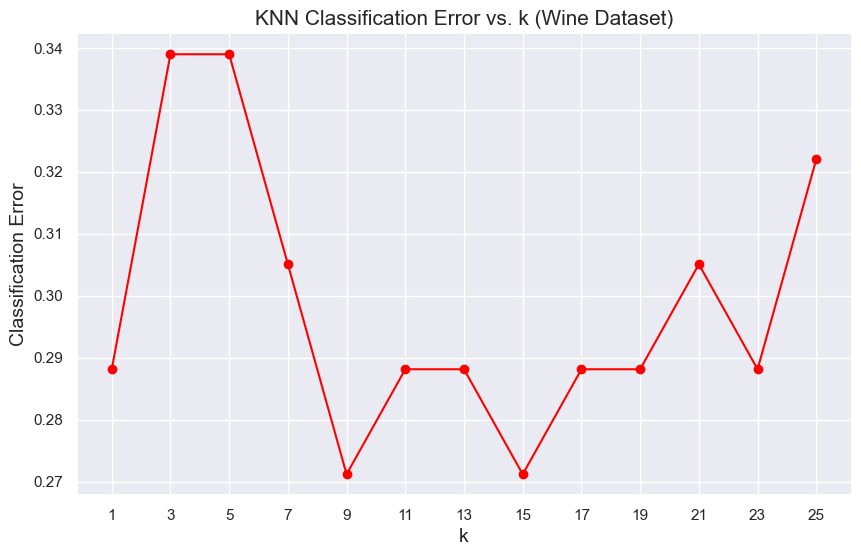

Best k = 9  (error = 0.2712)


In [13]:
plt.figure(figsize=(10, 6))
plt.plot(possible_k, errors, color="red", marker="o")
plt.xlabel("k", fontsize=14)
plt.ylabel("Classification Error", fontsize=14)
plt.title("KNN Classification Error vs. k (Wine Dataset)", fontsize=15)
plt.xticks(possible_k)
plt.show()

best_k = possible_k[errors.index(min(errors))]
print(f"Best k = {best_k}  (error = {min(errors):.4f})")

---

## 10. Evaluate at the Best $k$

Let us take a closer look at accuracy and per-class predictions using the best $k$.

---

In [14]:
y_pred = np.array([
    KNN_predict(point, X_train, y_train, k=best_k)
    for point in X_test
])

accuracy = 1 - classification_error(X_test, y_test, X_train, y_train, k=best_k)
print(f"Test accuracy (k={best_k}): {accuracy:.4f}")

# Simple per-class breakdown
for cls in range(3):
    mask   = y_test == cls
    cls_acc = np.mean(y_pred[mask] == cls)
    print(f"  {class_mapping[cls]:10s}  accuracy: {cls_acc:.4f}")

Test accuracy (k=9): 0.7288
  class_0     accuracy: 0.8000
  class_1     accuracy: 0.6957
  class_2     accuracy: 0.6875


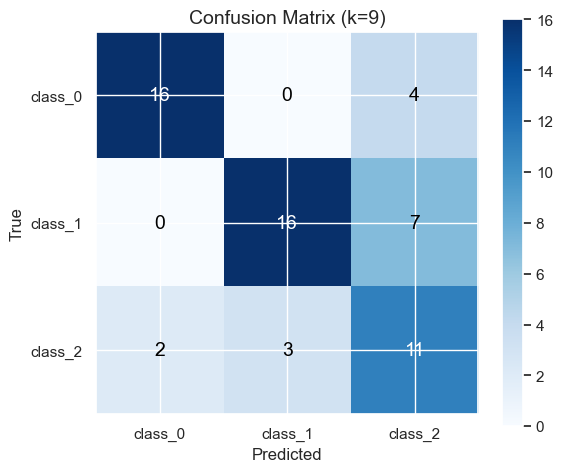

In [15]:
# Confusion matrix (manual)
conf = np.zeros((3, 3), dtype=int)
for true, pred in zip(y_test, y_pred):
    conf[true, pred] += 1

fig, ax = plt.subplots(figsize=(6, 5))
im = ax.imshow(conf, cmap="Blues")
ax.set_xticks(range(3)); ax.set_yticks(range(3))
ax.set_xticklabels([class_mapping[i] for i in range(3)])
ax.set_yticklabels([class_mapping[i] for i in range(3)])
ax.set_xlabel("Predicted", fontsize=12)
ax.set_ylabel("True", fontsize=12)
ax.set_title(f"Confusion Matrix (k={best_k})", fontsize=14)
plt.colorbar(im, ax=ax)

for i in range(3):
    for j in range(3):
        ax.text(j, i, str(conf[i, j]), ha="center", va="center",
                color="white" if conf[i, j] > conf.max() / 2 else "black",
                fontsize=14)

plt.tight_layout()
plt.show()

---

## 11. Wine Recommender System

Just as KNN powers many real-world recommendation engines, we can use it here to answer: *"Given a wine I liked, which other wines are most similar?"*

We build a small catalogue of labelled wines and find the $k$ nearest neighbours by chemical profile.

---

In [16]:
# Build a named wine catalogue — use the full dataset
wine_df = X_df.copy()
wine_df["cultivar"] = y_s.map(class_mapping)

# Give each wine a descriptive name: cultivar + index
wine_df.index = [
    f"{class_mapping[y_s[i]]}_wine_{i}" for i in range(len(y_s))
]

print("Catalogue shape:", wine_df.shape)
wine_df.head(8)

Catalogue shape: (178, 14)


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,cultivar
class_0_wine_0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,class_0
class_0_wine_1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,class_0
class_0_wine_2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,class_0
class_0_wine_3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,class_0
class_0_wine_4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,class_0
class_0_wine_5,14.20,1.76,2.45,15.2,112.0,3.27,3.39,0.34,1.97,6.75,1.05,2.85,1450.0,class_0
class_0_wine_6,14.39,1.87,2.45,14.6,96.0,2.50,2.52,0.30,1.98,5.25,1.02,3.58,1290.0,class_0
class_0_wine_7,14.06,2.15,2.61,17.6,121.0,2.60,2.51,0.31,1.25,5.05,1.06,3.58,1295.0,class_0


In [17]:
def wine_recommendations(wine_name, df, feature_cols, k):
    """
    Return the k most similar wines to wine_name
    (excluding itself).
    """
    X_cat = df[feature_cols].to_numpy()
    names = df.index.to_numpy()
    point = df.loc[wine_name, feature_cols].to_numpy()

    neighbors = k_nearest_neighbors(point, X_cat, names, k + 1)
    # First neighbor is the wine itself (distance ≈ 0); skip it
    return [x[1] for x in neighbors[1:]]

feature_cols = data.feature_names

query = "class_0_wine_0"
recs  = wine_recommendations(query, wine_df, feature_cols, k=5)

print(f"Because you liked  →  {query}")
print(f"  cultivar: {wine_df.loc[query, 'cultivar']}")
print()
print("You might also enjoy:")
for i, w in enumerate(recs, 1):
    cultivar = wine_df.loc[w, "cultivar"]
    print(f"  {i}. {w}  (cultivar: {cultivar})")

Because you liked  →  class_0_wine_0
  cultivar: class_0

You might also enjoy:
  1. class_0_wine_54  (cultivar: class_0)
  2. class_0_wine_45  (cultivar: class_0)
  3. class_0_wine_48  (cultivar: class_0)
  4. class_0_wine_46  (cultivar: class_0)
  5. class_0_wine_1  (cultivar: class_0)


In [18]:
# Try a different wine
query2 = "class_2_wine_130"
recs2  = wine_recommendations(query2, wine_df, feature_cols, k=5)

print(f"Because you liked  →  {query2}")
print(f"  cultivar: {wine_df.loc[query2, 'cultivar']}")
print()
print("You might also enjoy:")
for i, w in enumerate(recs2, 1):
    cultivar = wine_df.loc[w, "cultivar"]
    print(f"  {i}. {w}  (cultivar: {cultivar})")

Because you liked  →  class_2_wine_130
  cultivar: class_2

You might also enjoy:
  1. class_2_wine_169  (cultivar: class_2)
  2. class_1_wine_96  (cultivar: class_1)
  3. class_2_wine_154  (cultivar: class_2)
  4. class_1_wine_120  (cultivar: class_1)
  5. class_1_wine_62  (cultivar: class_1)


---

## 12. Summary

In this notebook we built the **$k$-Nearest Neighbors** algorithm from scratch and applied it to the Wine dataset.

### Key takeaways
- **Distance matters** — wines with similar chemical profiles (flavanoids, proline, etc.)   cluster together, making KNN effective.
- **Choosing $k$** — a sweep over odd values of $k$ reveals a minimum-error region;   values in this region generalize well.
- **Strengths of KNN**
  - Simple to implement and understand.
  - No training phase; the model is the data.
  - Naturally handles multi-class problems.
- **Weaknesses of KNN**
  - Slow at prediction time — must compute distances to all training points.
  - Sensitive to irrelevant or un-scaled features.
  - Memory-intensive for large datasets.
- **Recommender systems** — the same nearest-neighbor lookup that drives classification   can power product / content recommendation with no extra machinery.

---